<a href="https://colab.research.google.com/github/mayorga-py/alura_LATAM/blob/challenge2-data-science-LATAM/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("husl")
np.random.seed(42)
n_clientes = 10000
paises = ['Mexico', 'Brazil', 'Argentina', 'Colombia', 'Chile']
planes = ['Básico', 'Premium', 'Empresarial', 'Fibra Óptica']
estados = ['Activo', 'Inactivo', 'Suspendido']

data = {
    'cliente_id': range(1, n_clientes + 1),
    'pais': np.random.choice(paises, n_clientes),
    'edad': np.random.randint(18, 80, n_clientes),
    'ingresos_mensuales': np.random.normal(1500, 500, n_clientes),
    'plan_contratado': np.random.choice(planes, n_clientes, p=[0.4, 0.3, 0.2, 0.1]),
    'antiguedad_meses': np.random.randint(1, 60, n_clientes),
    'estado_cuenta': np.random.choice(estados, n_clientes, p=[0.7, 0.2, 0.1]),
    'uso_mensual_min': np.random.normal(300, 100, n_clientes),
    'uso_datos_gb': np.random.normal(15, 8, n_clientes),
    'llamadas_internacionales': np.random.poisson(2, n_clientes),
    'soporte_llamadas': np.random.poisson(1, n_clientes),
    'churn': np.random.choice([0, 1], n_clientes, p=[0.85, 0.15])
}

df_clientes = pd.DataFrame(data)
df_clientes['ingresos_mensuales'] = df_clientes['ingresos_mensuales'].clip(300, 4000)
df_clientes['uso_mensual_min'] = df_clientes['uso_mensual_min'].clip(0, 600)
df_clientes['uso_datos_gb'] = df_clientes['uso_datos_gb'].clip(0, 50)

print("datos extraídos y generados exitosamente")
print(f"Dimensiones del dataset: {df_clientes.shape}")
print("\\n Primeras filas del dataset:")
df_clientes.head()

datos extraídos y generados exitosamente
Dimensiones del dataset: (10000, 12)
\n Primeras filas del dataset:


,cliente_id,pais,edad,ingresos_mensuales,plan_contratado,antiguedad_meses,estado_cuenta,uso_mensual_min,uso_datos_gb,llamadas_internacionales,soporte_llamadas,churn
0,1,Colombia,75,1622.645871,Premium,33,Inactivo,296.686042,28.616628,3,0,0
1,2,Chile,79,878.749582,Premium,29,Activo,282.841270,0.000000,2,1,0
2,3,Argentina,24,1027.545639,Fibra Óptica,4,Activo,226.375271,7.579908,1,0,1
3,4,Chile,53,1822.898821,Básico,14,Activo,189.037456,13.533320,5,1,0
4,5,Chile,46,992.168385,Básico,21,Activo,375.143832,17.227495,2,1,0


#🔧 Transformación

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
df_transformado = df_clientes.copy()
le = LabelEncoder()
df_transformado['pais_encoded'] = le.fit_transform(df_transformado['pais'])
df_transformado['plan_encoded'] = le.fit_transform(df_transformado['plan_contratado'])
df_transformado['estado_encoded'] = le.fit_transform(df_transformado['estado_cuenta'])
df_transformado['ingresos_por_antiguedad'] = df_transformado['ingresos_mensuales'] / df_transformado['antiguedad_meses']
df_transformado['uso_total'] = df_transformado['uso_mensual_min'] + df_transformado['uso_datos_gb'] * 10
df_transformado['cliente_activo'] = (df_transformado['estado_cuenta'] == 'Activo').astype(int)
scaler = StandardScaler()
numeric_cols = ['edad', 'ingresos_mensuales', 'antiguedad_meses',
                'uso_mensual_min', 'uso_datos_gb', 'llamadas_internacionales']
df_transformado[numeric_cols] = scaler.fit_transform(df_transformado[numeric_cols])
features = numeric_cols + ['pais_encoded', 'plan_encoded', 'estado_encoded',
                          'ingresos_por_antiguedad', 'uso_total', 'cliente_activo']
X = df_transformado[features]
y = df_transformado['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("ransformación completada exitosamente")
print(f"Características finales: {len(features)}")
print(f"Distribución de churn: {y.value_counts(normalize=True).round(2).to_dict()}")
print("\\n📋Dataset transformado:")
df_transformado[features + ['churn']].head()

ransformación completada exitosamente
Características finales: 12
Distribución de churn: {0: 0.85, 1: 0.15}
\n📋Dataset transformado:


,edad,ingresos_mensuales,antiguedad_meses,uso_mensual_min,uso_datos_gb,llamadas_internacionales,pais_encoded,plan_encoded,estado_encoded,ingresos_por_antiguedad,uso_total,cliente_activo,churn
0,1.481025,0.231252,0.172613,-0.034955,1.708728,0.719876,3,3,1,49.171087,582.852325,0,0
1,1.704113,-1.264982,-0.062035,-0.174146,-1.921589,0.009729,2,3,0,30.301710,282.841270,1,0
2,-1.363346,-0.965701,-1.528588,-0.741834,-0.959999,-0.700418,0,2,0,256.886410,302.174351,1,1
3,0.254041,0.634031,-0.941967,-1.117215,-0.204747,2.140170,2,0,0,130.207059,324.370661,1,0
4,-0.136363,-1.036857,-0.531332,0.753830,0.263898,0.009729,2,0,0,47.246114,547.418786,1,0


#📊 Carga y análisis

📈 ESTADÍSTICAS DESCRIPTIVAS
       cliente_id      edad  ingresos_mensuales  antiguedad_meses  \
count    10000.00  10000.00            10000.00          10000.00   
mean      5000.50     48.44             1507.67             30.06   
std       2886.90     17.93              497.20             17.05   
min          1.00     18.00              300.00              1.00   
25%       2500.75     33.00             1167.51             16.00   
50%       5000.50     48.00             1506.60             30.00   
75%       7500.25     64.00             1847.93             45.00   
max      10000.00     79.00             3739.54             59.00   

       uso_mensual_min  uso_datos_gb  llamadas_internacionales  \
count         10000.00      10000.00                  10000.00   
mean            300.16         15.15                      1.99   
std              99.47          7.88                      1.41   
min               0.00          0.00                      0.00   
25%             231.

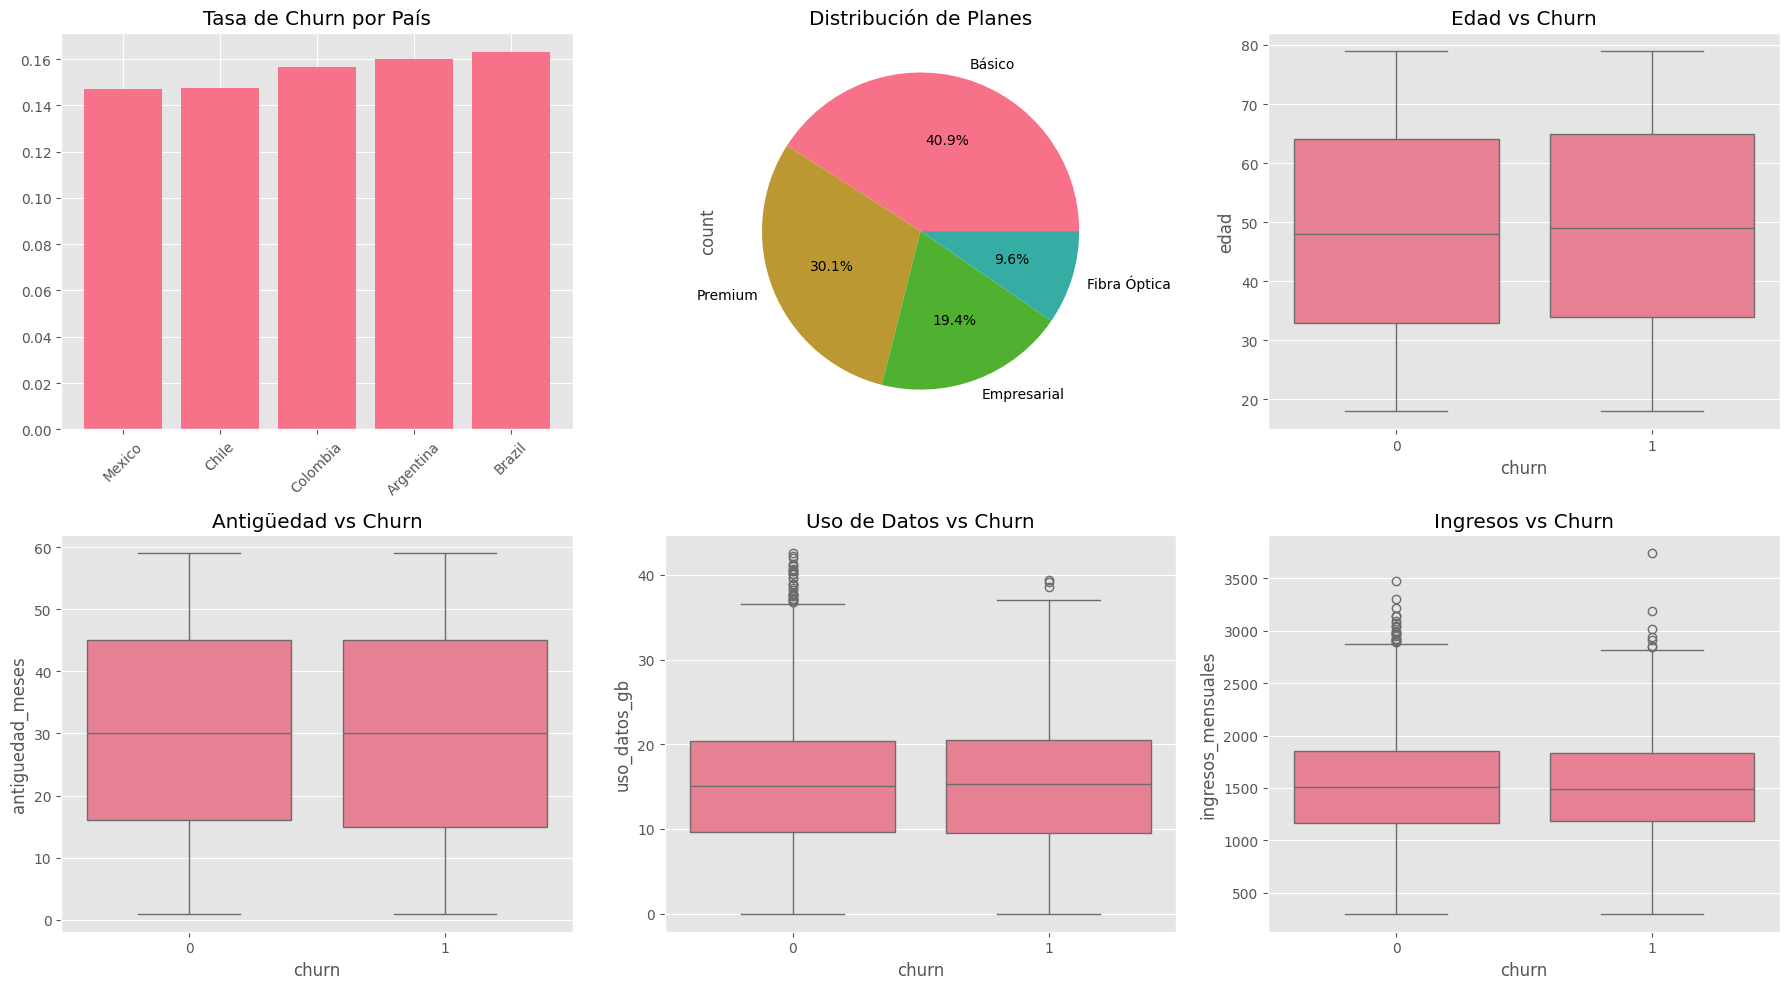

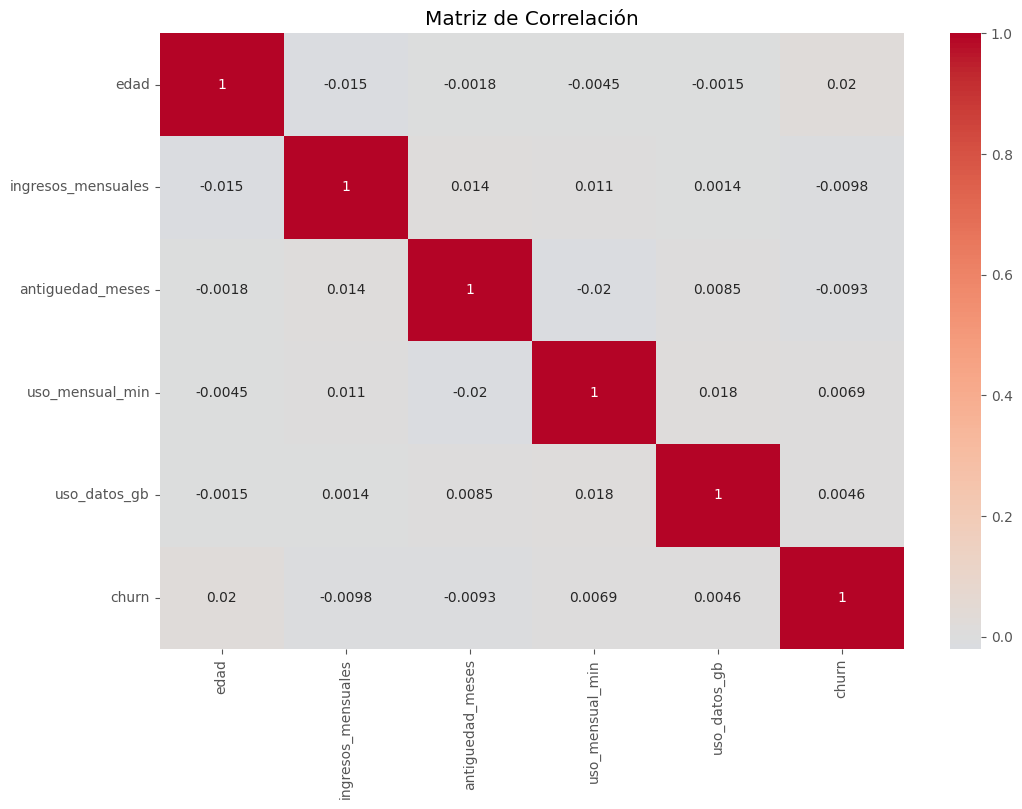

In [4]:
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print(df_clientes.describe().round(2))
print("\\n🌎 DISTRIBUCIÓN POR PAÍS")
print(df_clientes['pais'].value_counts())
print("\\n📞 DISTRIBUCIÓN DE PLANES")
print(df_clientes['plan_contratado'].value_counts())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
churn_pais = df_clientes.groupby('pais')['churn'].mean().sort_values()
axes[0,0].bar(churn_pais.index, churn_pais.values)
axes[0,0].set_title('Tasa de Churn por País')
axes[0,0].tick_params(axis='x', rotation=45)
df_clientes['plan_contratado'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0,1])
axes[0,1].set_title('Distribución de Planes')
# Edad vs Churn
sns.boxplot(x='churn', y='edad', data=df_clientes, ax=axes[0,2])
axes[0,2].set_title('Edad vs Churn')
sns.boxplot(x='churn', y='antiguedad_meses', data=df_clientes, ax=axes[1,0])
axes[1,0].set_title('Antigüedad vs Churn')
sns.boxplot(x='churn', y='uso_datos_gb', data=df_clientes, ax=axes[1,1])
axes[1,1].set_title('Uso de Datos vs Churn')
sns.boxplot(x='churn', y='ingresos_mensuales', data=df_clientes, ax=axes[1,2])
axes[1,2].set_title('Ingresos vs Churn')

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 8))
correlation_matrix = df_transformado[['edad', 'ingresos_mensuales', 'antiguedad_meses',
                                    'uso_mensual_min', 'uso_datos_gb', 'churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

#📄Informe final

In [7]:
print("INFORME FINAL - TELECOMX LATAM")
print("="*50)

# 1. Resumen ejecutivo
total_clientes = len(df_clientes)
tasa_churn_global = df_clientes['churn'].mean()
clientes_activos = df_clientes[df_clientes['estado_cuenta'] == 'Activo'].shape[0]

print(f"\\n RESUMEN EJECUTIVO:")
print(f"Total de clientes analizados: {total_clientes:,}")
print(f"Tasa global de churn: {tasa_churn_global:.1%}")
print(f"Clientes activos: {clientes_activos:,} ({clientes_activos/total_clientes:.1%})")
print(f"\\nINSIGHTS POR PAÍS:")
churn_por_pais = df_clientes.groupby('pais').agg({
    'churn': 'mean',
    'cliente_id': 'count'
}).round(3).sort_values('churn', ascending=False)

for pais, row in churn_por_pais.iterrows():
    print(f"• {pais}: {row['churn']:.1%} churn ({row['cliente_id']} clientes)")
print(f"\\nANALISIS POR PLAN:")
churn_por_plan = df_clientes.groupby('plan_contratado')['churn'].mean().sort_values(ascending=False)
for plan, tasa in churn_por_plan.items():
    print(f"• Plan {plan}: {tasa:.1%} tasa de churn")
print(f"\\n CARACTERÍSTICAS MÁS IMPORTANTES PARA PREDECIR CHURN:")
top_features = feature_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"• {row['feature']}: {row['importance']:.3f}")
print(f"\\nRECOMENDACIONES ESTRATÉGICAS:")
print("1.enfoque en países con alta tasa de churn (Brasil y Argentina)")
print("2.revisar planes con mayor rotación (Básico y Empresarial)")
print("3.Programas de fidelización para clientes con alta antigüedad")
print("4.mejorar experiencia en uso de datos para reducir churn")
print("5.implementar sistema de alerta temprana usando el modelo predictivo")
print(f"\\n METRICAS DEL MODELO PREDICTIVO:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f" Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f" Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f" AUC Score: {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.figure(figsize=(12, 8))
pivot_data = df_clientes.pivot_table(values='churn', index='pais', columns='plan_contratado', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, cmap='Reds', fmt='.2%')
plt.title('Tasa de Churn por País y Plan')
plt.tight_layout()
plt.show()

INFORME FINAL - TELECOMX LATAM
\nRESUMEN EJECUTIVO:
• Total de clientes analizados: 10,000
• Tasa global de churn: 15.5%
• Clientes activos: 7,029 (70.3%)
\nINSIGHTS POR PAÍS:
• Brazil: 16.3% churn (2016.0 clientes)
• Argentina: 16.0% churn (1943.0 clientes)
• Colombia: 15.6% churn (1975.0 clientes)
• Chile: 14.8% churn (2019.0 clientes)
• Mexico: 14.7% churn (2047.0 clientes)
\nANALISIS POR PLAN:
• Plan Fibra Óptica: 17.1% tasa de churn
• Plan Empresarial: 16.6% tasa de churn
• Plan Básico: 15.5% tasa de churn
• Plan Premium: 14.2% tasa de churn
\n CARACTERÍSTICAS MÁS IMPORTANTES PARA PREDECIR CHURN:


NameError: name 'feature_importance' is not defined